In [6]:
pip install scikit learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikit (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for scikit


In [7]:
pip matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "matplotlib"



In [8]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix

In [4]:
df=pd.read_csv("C:\\Users\\user\\OneDrive\\Desktop\\Full Stack\\HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


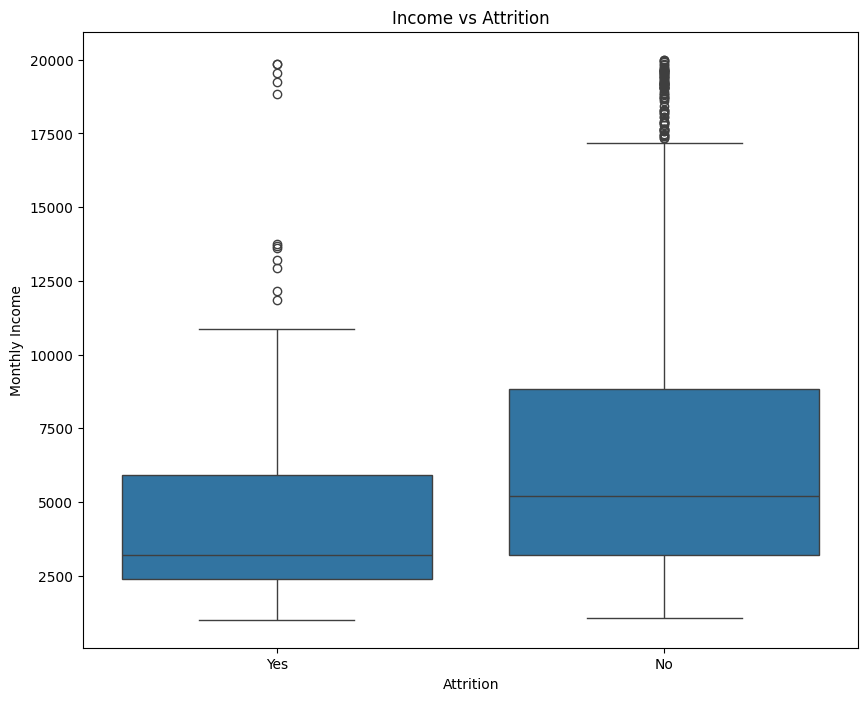

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

step3:

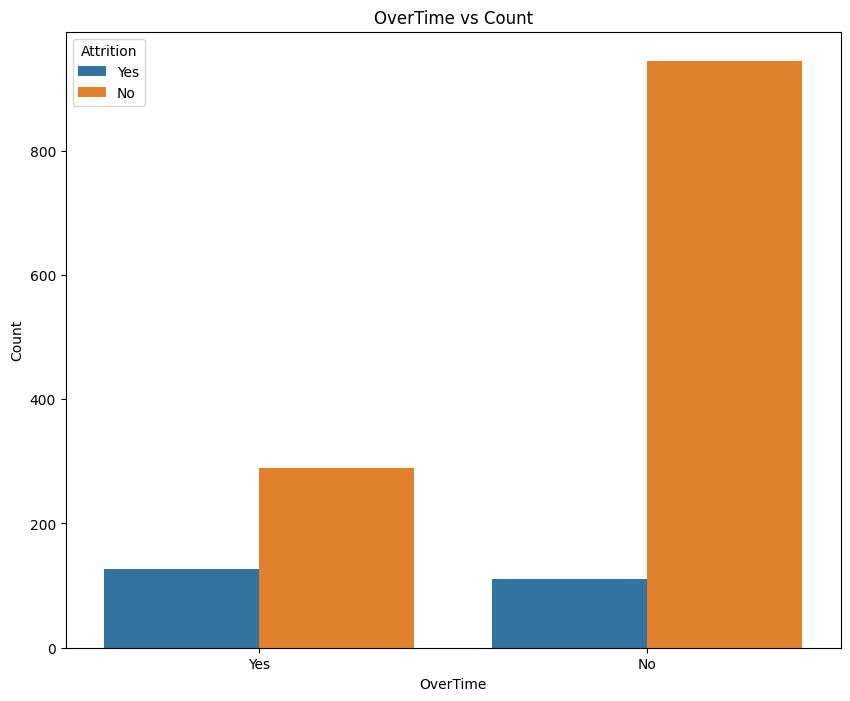

In [10]:
plt.figure(figsize=(10,8))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Count")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [15]:
#drop irrelevant columns
#df.info()
#encode categorial varaiables
encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    encoder[col]=lb
X=df.drop("Attrition",axis=1)#independent var
y=df["Attrition"]#dependent var
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

In [12]:
rf=RandomForestClassifier(random_state=42)
param_grid={
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
}
grid_search=GridSearchCV(rf,param_grid,cv=5,scoring='f1')
grid_search.fit(X_train,y_train)
print("Best Hyperparameters:",grid_search.best_params_)

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [13]:
model=RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(X,y)
joblib.dump(model,"employee_attrition_model.pkl")
joblib.dump(lb,"label_encoder.pkl")
joblib.dump(X.columns.to_list(),"feature_columns.pkl")
print("installed successfully")

installed successfully


              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'Feature')

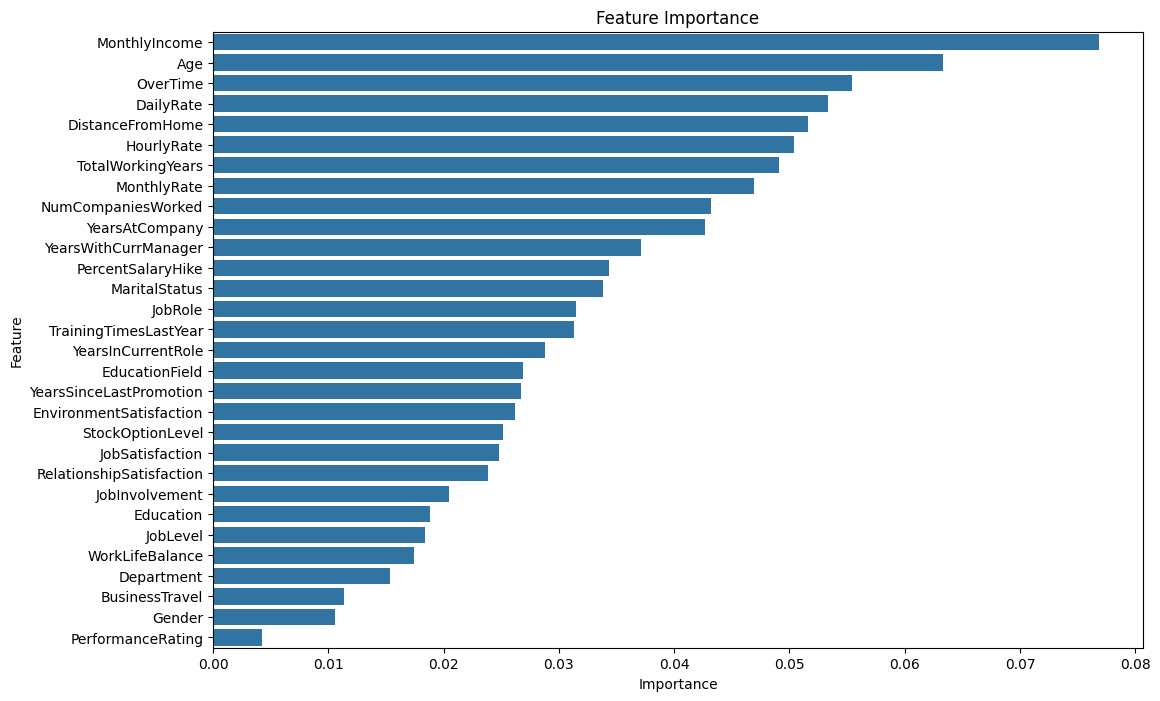

In [14]:
best_model=grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))
importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importances
    }).sort_values(by="Importance",ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")